In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from nested_pandas import read_parquet
import numpy as np

In [2]:
nf = read_parquet('/global/cfs/cdirs/desc-td/users/mdai/fastdb_dumps/out_dir/mjd_61080_61110_0008.parquet')
print(f'{len(nf)} objects')
nf.head()

563 objects


ra        dec           diaobjectid  \
0    58.28774 -50.236214  [170028489608527927]   
1  148.931305    3.07547  [170046105772359693]   
2   64.489778 -46.908314  [170028487828570124]   
3   60.164884 -50.298214  [170050484337377337]   
4  187.023053   6.845958  [170028531476070462]   

                                          lightcurve  \
0  [{diaforcedsourceid: NaN, diasourceid: 1.70028...   
1  [{diaforcedsourceid: NaN, diasourceid: 1700461...   
2  [{diaforcedsourceid: NaN, diasourceid: 1.70028...   
3  [{diaforcedsourceid: NaN, diasourceid: 1700504...   
4  [{diaforcedsourceid: NaN, diasourceid: 1.70028...   

                                 rootid  
0  fc8552bd-4214-401b-84c2-14bb329ea7cb  
1  fc86bd7e-3e23-471c-be97-37db3e7267dd  
2  fc887789-040a-4f6a-9464-21a2298880bf  
3  fc8914c3-967f-4328-a5ae-70db31abfb25  
4  fc89a733-cd47-4aad-9f49-3acb2299fe9c

In [3]:
# compute some quanties
from nested_pandas.utils import count_nested

nf = count_nested(nf.query("lightcurve.isdet == True"),by="band",nested="lightcurve")
nf = count_nested(nf.query("lightcurve.isdet == True"),by="isdet",nested="lightcurve")
nf = nf.rename(columns = {"n_lightcurve_True": "ndet"})
nf["lightcurve.snr"] = nf["lightcurve.flux"]/nf["lightcurve.fluxerr"]
nf = nf.map_rows(lambda row: np.sum(np.unique_counts(row).counts>0), columns="lightcurve.band", row_container="args", output_names="nbands", append_columns=True)

# # filter objects

nf = nf.query("ndet > 10 and "
              "nbands > 2")


/global/common/software/lsst/install/td_env/2026-05-28-05-05/py/envs/td_env/lib/python3.12/site-packages/nested_pandas/nestedframe/core.py:1476: RuntimeWarning: Engine has switched to 'python' because numexpr does not support extension array dtypes. Please set your engine to python manually.
  answer = super().eval(expr, **kwargs)
/global/common/software/lsst/install/td_env/2026-05-28-05-05/py/envs/td_env/lib/python3.12/site-packages/nested_pandas/nestedframe/core.py:1476: RuntimeWarning: Engine has switched to 'python' because numexpr does not support extension array dtypes. Please set your engine to python manually.
  answer = super().eval(expr, **kwargs)
/global/common/software/lsst/install/td_env/2026-05-28-05-05/py/envs/td_env/lib/python3.12/site-packages/nested_pandas/nestedframe/core.py:1476: RuntimeWarning: Engine has switched to 'python' because numexpr does not support extension array dtypes. Please set your engine to python manually.
  answer = super().eval(expr, **kwargs)


In [4]:
def lc_quality_cuts(flux,mjd,filter,snr, n_phases=5, n_before_peak=1, n_after_peak=2, n_bands=3):
    det = snr > 5
    flux = flux[det]
    mjd = mjd[det]
    filter = filter[det]
    if len(flux) == 0:
        return False
    peak_idx = np.argmax(flux)
    phases = np.floor((mjd - mjd[peak_idx]))
    unique_phases,unique_idx = np.unique(phases,return_index=True)
    good_idx = (unique_phases >= -40) & (unique_phases<=100)
    pass_cut = len(unique_phases[good_idx]) >= n_phases
    flux_new = flux[unique_idx][good_idx]
    peak_idx_new = np.argmax(flux_new)
    pass_cut &= (peak_idx_new >= n_before_peak - 1) & (len(flux_new) - peak_idx_new >= n_after_peak - 1)
    good_phases = (phases >= -40) & (phases<=100)
    pass_cut &= len(np.unique(filter[good_phases])) >= n_bands
    return pass_cut

In [5]:
nf = nf.map_rows(lc_quality_cuts,
                 columns=["lightcurve.flux",
                          "lightcurve.mjd",
                          "lightcurve.band",
                          "lightcurve.snr"],
                 row_container="args",
                 output_names="pass_quality_cuts",
                 append_columns=True)

In [11]:
nf = nf.query("pass_quality_cuts == True")

In [14]:
colors = {"u": "blue",
          "g": "green",
          "r": "red",
          "i": "purple",
          "z": "orange",
          "y": "brown"}
def plot_lc(lc,saltpars=None):
    maxflux = 0.
    for f in lc["band"].unique():
        lc_f = lc.loc[lc["band"]==f]
        is_det = np.absolute(lc_f["snr"]) > 5
        lc_det = lc_f.loc[is_det]
        lc_nondet = lc_f.loc[~is_det]
        plt.errorbar(lc_det["mjd"],lc_det["flux"],yerr=lc_det["fluxerr"],fmt='o',label=f, c=colors[f])
        plt.errorbar(lc_nondet["mjd"],lc_nondet["flux"],yerr=lc_nondet["fluxerr"],fmt='>',alpha=0.3, c=colors[f])

        if saltpars is not None:
            model = sncosmo.Model("salt3",effects=[sncosmo.F99Dust()], effect_names=["mw"], effect_frames=["obs"])
            model.update(saltpars)
            time = np.linspace(-20,50,100)*(1.+saltpars["z"]) + saltpars["t0"]
            try:
                flux = model.bandflux("lsst"+f,time,zp=31.4, zpsys='ab')
                maxflux = np.max(np.append(flux,maxflux))
                plt.plot(time,flux,c=colors[f],alpha=0.1,ls="--")
            except:
                continue
        plt.legend()
    is_det = np.absolute(lc["snr"]) > 5
    if saltpars:
        ylim = (-0.2*maxflux, maxflux*1.5)
    else:
        ylim = (-0.2*lc.loc[is_det]["flux"].max(),lc.loc[is_det]["flux"].max()*1.5)
    plt.ylim(ylim)

seed=[685]


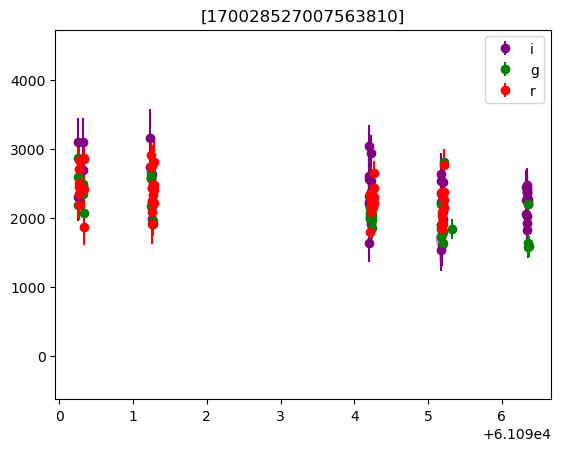

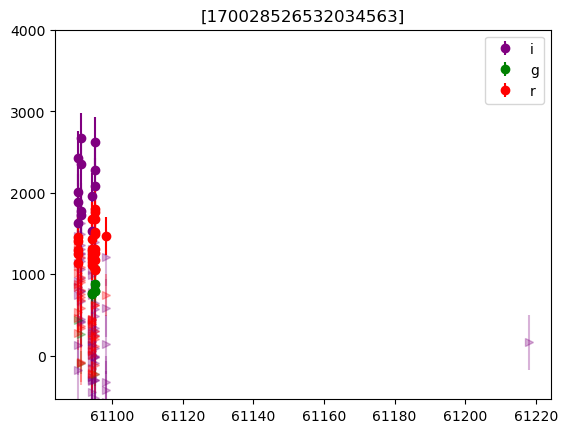

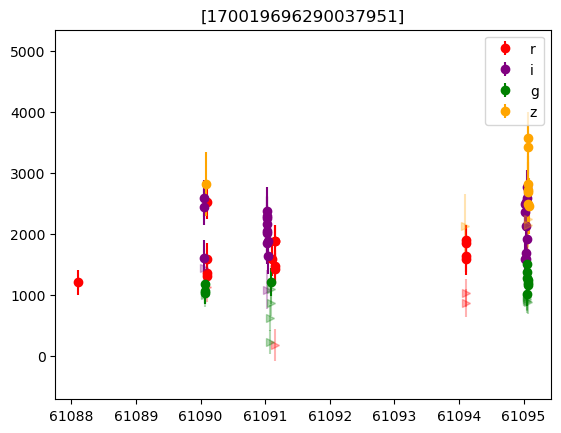

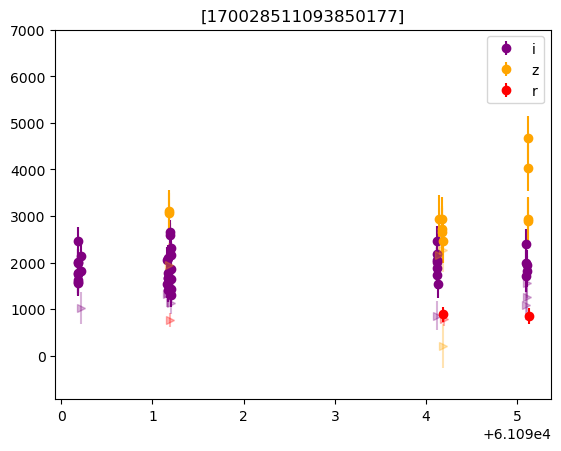

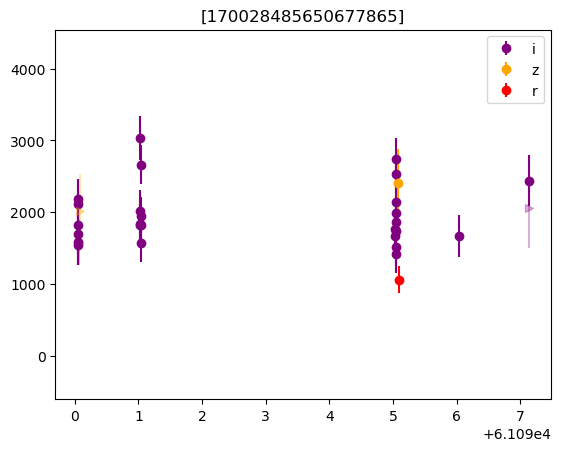

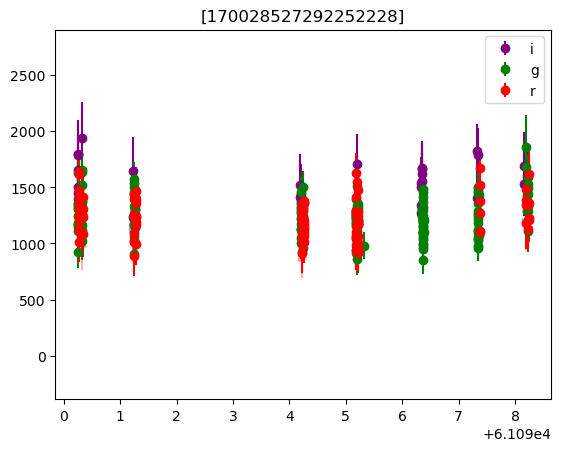

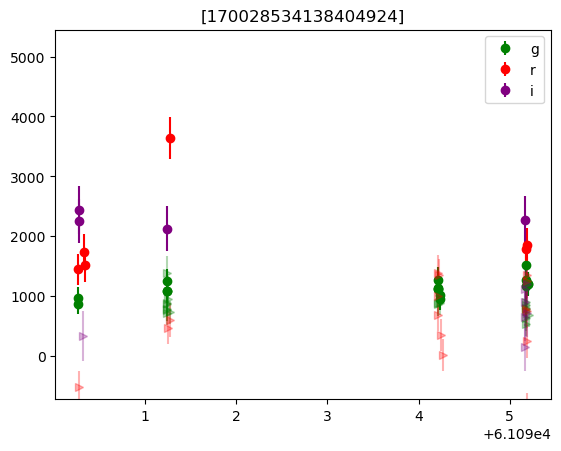

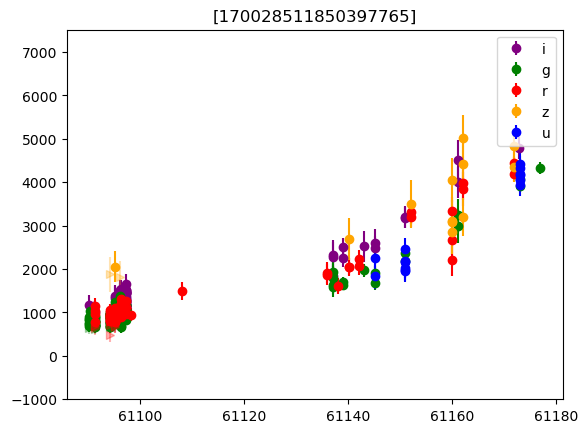

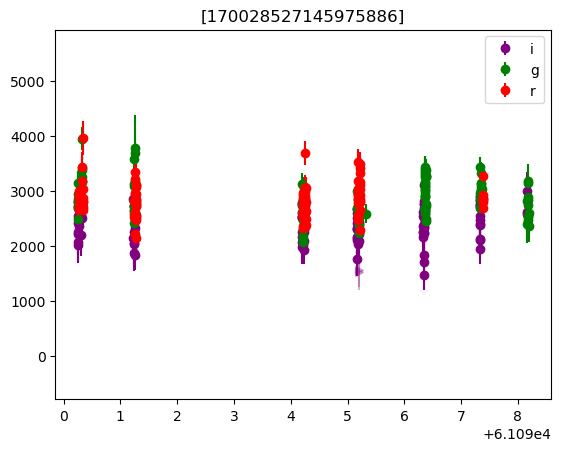

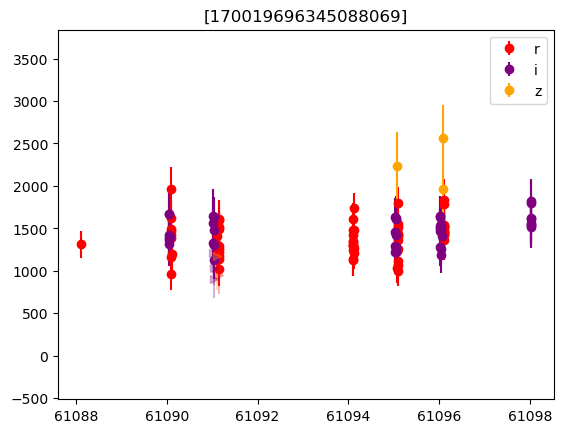

In [33]:
seed = np.random.randint(0,10000,1)
print(f"seed={seed}")
rng = np.random.default_rng(seed)
for i in rng.choice(len(nf),size=np.min([10,len(nf)]),replace=False):
    lc = nf.iloc[i]["lightcurve"]
    plot_lc(lc)
    plt.title(nf.iloc[i]["diaobjectid"])
    plt.show()